# Weather Underground Data: Fetch → Clean → Check
## Complete Pipeline with Precipitation Focus

**Features:**
1. ✅ Fetch data with auto-chunking (64+ days)
2. ✅ Convert to clean column names (precipitation FIRST!)
3. ✅ Quality checks and validation
4. ✅ Precipitation-focused analysis
5. ✅ Export to multiple formats

**Note:** API key is loaded from `src/config.py` (set `WU_API_KEY_LOCAL` or use environment variable `WU_API_KEY`)

## 1. Setup & Configuration

In [1]:
import sys
import os
from pathlib import Path
from datetime import datetime
import pandas as pd

# Add project root to path
# Try to find project root by looking for 'src' directory
current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if project_root is None:
    # Fallback: assume we're in project root or one level up
    project_root = current_dir if (current_dir / 'src').exists() else current_dir.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import functions
from src.fetch_data.weather_underground.wu_functions import (
    run_wu_pipeline, 
    export_wu_data,
    read_pws_metadata,
    get_station_list
)
from src.fetch_data.weather_underground.wu_plotting import (
    plot_precipitation_analysis,
    plot_precipitation_analysis_multi,
    plot_cumulative_precipitation,
    plot_cumulative_precipitation_multi,
    plot_weather_dashboard,
    plot_weather_dashboard_multi,
    check_data_quality
)
from src.config import get_wu_api_key

# Load API key from config
API_KEY = get_wu_api_key()
if not API_KEY:
    raise ValueError("API key not found! Set WU_API_KEY_LOCAL in src/config.py or environment variable WU_API_KEY")

print("✅ All imports successful!")

✅ All imports successful!


### Option A: Manual Station List
Set `STATION_IDS` directly below.

### Option B: Load from Metadata
Use `read_pws_metadata()` to load station list from CSV file.


In [2]:
# --- STATION SELECTION OPTIONS ---
USE_METADATA = False  # True: load all stations from metadata; False: manually set list

if USE_METADATA:
    pws_metadata = read_pws_metadata()
    # Example: filter to just New York City
    # nyc_cities = {"New York", "Brooklyn", "Bronx", "Queens", "Staten Island"}
    # STATION_IDS = pws_metadata[pws_metadata["City"].isin(nyc_cities)]["Station ID"].tolist()
    STATION_IDS = get_station_list(pws_metadata)
else:
    STATION_IDS = ["KNYNEWYO1805", "KNYNEWYO1288"]  # or fill with list of desired station IDs

START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2024, 1, 30)
UNITS = 'm'  # 'm' = metric, 'e' = English
OUTPUT_DIR = Path('../../data/wu_pws')

FETCH_OPTIONS = {
    'current': False,
    'rapid': False,
    'historical': True,
    'hourly': False,
    'daily': False,
}

print(f"✓ Config: {len(STATION_IDS)} stations, {START_DATE.date()} to {END_DATE.date()} ({(END_DATE - START_DATE).days}d)")



✓ Config: 2 stations, 2024-01-01 to 2024-01-30 (29d)


## 2. Fetch Data

In [3]:
# Run the complete pipeline
results = run_wu_pipeline(
    api_key=API_KEY,
    station_ids=STATION_IDS,
    start_date=START_DATE,
    end_date=END_DATE,
    units=UNITS,
    fetch_options=FETCH_OPTIONS,
    output_dir=None,
    save_data=False
)

if results and results.get('raw_data'):
    total_obs = results['summary']['total_observations']
    print(f"✓ Fetched: {total_obs:,} observations from {len(STATION_IDS)} stations")
else:
    print("❌ No data fetched")

FETCHING DATA FROM WEATHER UNDERGROUND API

Fetching data for station: KNYNEWYO1805
  → Fetching historical data (2024-01-01 to 2024-01-30)...
    ✓ Historical data fetched (720 total observations)

Fetching data for station: KNYNEWYO1288
  → Fetching historical data (2024-01-01 to 2024-01-30)...
    ✓ Historical data fetched (720 total observations)
✓ Success: Fetched 1,440 observations in 0.5s
✓ Stations processed: 2/2

CONVERTING TO DATAFRAME WITH CLEAN NAMES

Processing station: KNYNEWYO1805
  ✓ Created DataFrame: 720 rows, 37 columns

Processing station: KNYNEWYO1288
  ✓ Created DataFrame: 720 rows, 37 columns

✓ Processed 2 station(s)
✓ Fetched: 1,440 observations from 2 stations


## 3. Convert to DataFrame with Clean Names
**Precipitation columns come FIRST!**


In [4]:
if results and 'dataframes' in results:
    all_dfs = results['dataframes']
    all_metadata = results['metadata']
    
    print(f"✅ Processed {len(all_dfs)} station(s)")
    
    # Store all stations' data
    station_data = {}
    for station_id, dfs in all_dfs.items():
        station_data[station_id] = {
            'raw': dfs['raw'],
            'clean': dfs['clean'],
            'metadata': all_metadata[station_id]
        }
    
    # For convenience: if single station, create df, df_raw, metadata variables
    if len(all_dfs) == 1:
        station_id = list(all_dfs.keys())[0]
        df_raw = all_dfs[station_id]['raw']
        df_clean = all_dfs[station_id]['clean']
        df = df_clean.copy()
        metadata = all_metadata[station_id]
        
        print(f"\n✅ Single station mode - convenience variables created:")
        print(f"   • df, df_raw, df_clean, metadata for station: {station_id}")
    else:
        print(f"\n✅ Multiple stations mode - access via station_data dictionary:")
        print(f"   • station_data['{list(all_dfs.keys())[0]}']['clean'] - for each station")
    
    # Show sample for first station
    first_station = list(all_dfs.keys())[0]
    df_sample = all_dfs[first_station]['clean']
    
    print(f"\n📋 Sample from first station ({first_station}):")
    print(f"   Rows: {len(df_sample)}, Columns: {len(df_sample.columns)}")
    print(f"\n📋 Clean column names (PRECIPITATION FIRST!):")
    for i, col in enumerate(df_sample.columns[:15], 1):
        marker = "🌧️ " if 'precip' in col else "  "
        print(f"{marker}{i:2d}. {col}")
    
    print("\n📦 Available DataFrames:")
    if len(all_dfs) == 1:
        print("  • df, df_raw, df_clean  : Single station data")
        print("  • metadata              : Column descriptions")
    else:
        print("  • station_data          : Dict with all stations")
        print("    - station_data[station_id]['raw']")
        print("    - station_data[station_id]['clean']")
        print("    - station_data[station_id]['metadata']")
else:
    print("❌ No data to convert")


✅ Processed 2 station(s)

✅ Multiple stations mode - access via station_data dictionary:
   • station_data['KNYNEWYO1805']['clean'] - for each station

📋 Sample from first station (KNYNEWYO1805):
   Rows: 720, Columns: 37

📋 Clean column names (PRECIPITATION FIRST!):
🌧️  1. precip_rate
🌧️  2. precip_total
   3. time_local
   4. time_utc
   5. timestamp_unix
   6. station_id
   7. latitude
   8. longitude
   9. timezone
  10. temp_avg
  11. temp_high
  12. temp_low
  13. dewpoint_avg
  14. dewpoint_high
  15. dewpoint_low

📦 Available DataFrames:
  • station_data          : Dict with all stations
    - station_data[station_id]['raw']
    - station_data[station_id]['clean']
    - station_data[station_id]['metadata']


## 4. Precipitation Analysis & Checker


In [5]:
# Preview data
if 'df' in locals():
    print(f"📊 Preview of single station data:")
    print(df.head())
elif 'station_data' in locals():
    first_station = list(station_data.keys())[0]
    print(f"📊 Preview of first station ({first_station}):")
    print(station_data[first_station]['clean'].head())
else:
    print("❌ No data available. Run the fetch and convert cells first.")


📊 Preview of first station (KNYNEWYO1805):
   precip_rate  precip_total          time_local                  time_utc  \
0          0.0           0.0 2024-01-01 00:58:23 2024-01-01 05:58:23+00:00   
1          0.0           0.0 2024-01-01 01:58:22 2024-01-01 06:58:22+00:00   
2          0.0           0.0 2024-01-01 02:58:21 2024-01-01 07:58:21+00:00   
3          0.0           0.0 2024-01-01 03:59:21 2024-01-01 08:59:21+00:00   
4          0.0           0.0 2024-01-01 04:59:18 2024-01-01 09:59:18+00:00   

   timestamp_unix    station_id  latitude  longitude          timezone  \
0      1704088703  KNYNEWYO1805    40.638    -74.035  America/New_York   
1      1704092302  KNYNEWYO1805    40.638    -74.035  America/New_York   
2      1704095901  KNYNEWYO1805    40.638    -74.035  America/New_York   
3      1704099561  KNYNEWYO1805    40.638    -74.035  America/New_York   
4      1704103158  KNYNEWYO1805    40.638    -74.035  America/New_York   

   temp_avg  ...  wind_gust_avg  wind_gust_

💧 KNYNEWYO1805: 165.2 mm total, 99 events
💧 KNYNEWYO1288: 498.7 mm total, 98 events


/Users/drorjac/PycharmProjects/OpenMesh-fresh/src/fetch_data/weather_underground/wu_plotting.py:63: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  plt.tight_layout()
/Users/drorjac/miniforge3/envs/openmesh/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/drorjac/miniforge3/envs/openmesh/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


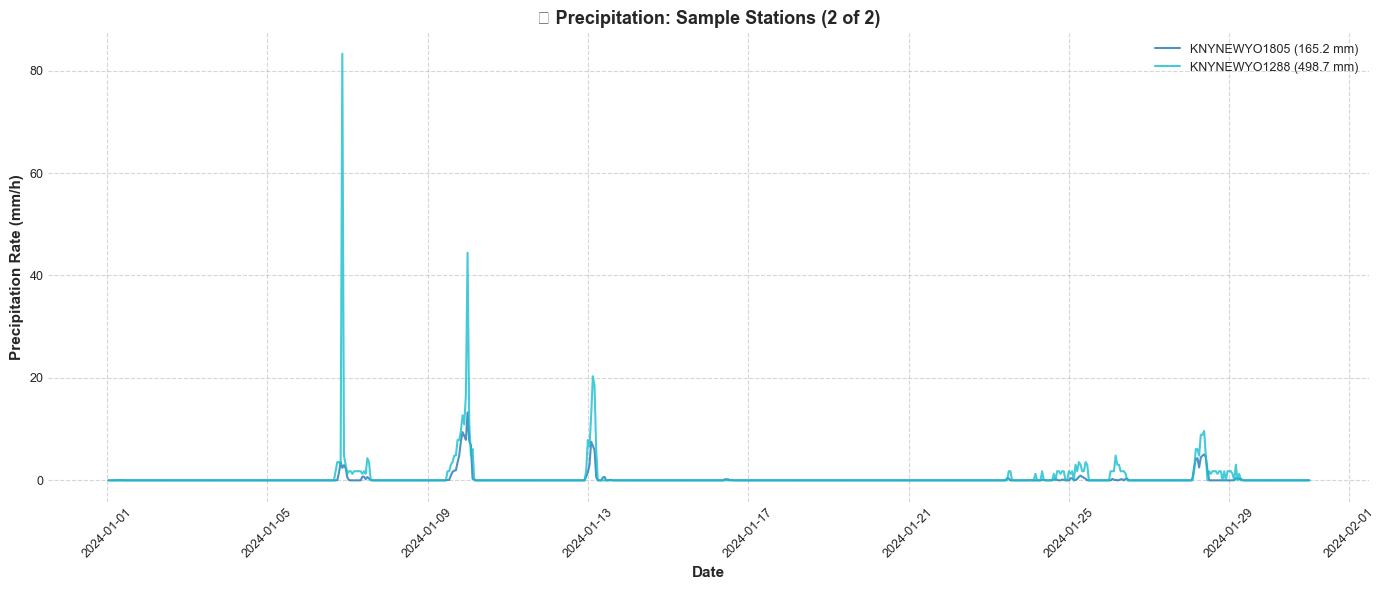

In [6]:
# Precipitation analysis (sample of 3-4 stations in one plot)
if 'df' in locals() and len(df) > 0:
    plot_precipitation_analysis(df, STATION_IDS[0], units=UNITS, show=False, verbose=False)
elif 'station_data' in locals():
    plot_precipitation_analysis_multi(station_data, units=UNITS, show=False, max_stations=4, verbose=False)
else:
    print("❌ No data available")


## 4.1 Cumulative Precipitation Analysis


📈 KNYNEWYO1805: 165.2 mm total, 99 events
📈 KNYNEWYO1288: 498.7 mm total, 98 events


/Users/drorjac/PycharmProjects/OpenMesh-fresh/src/fetch_data/weather_underground/wu_plotting.py:123: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  plt.tight_layout()
/Users/drorjac/miniforge3/envs/openmesh/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/drorjac/miniforge3/envs/openmesh/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


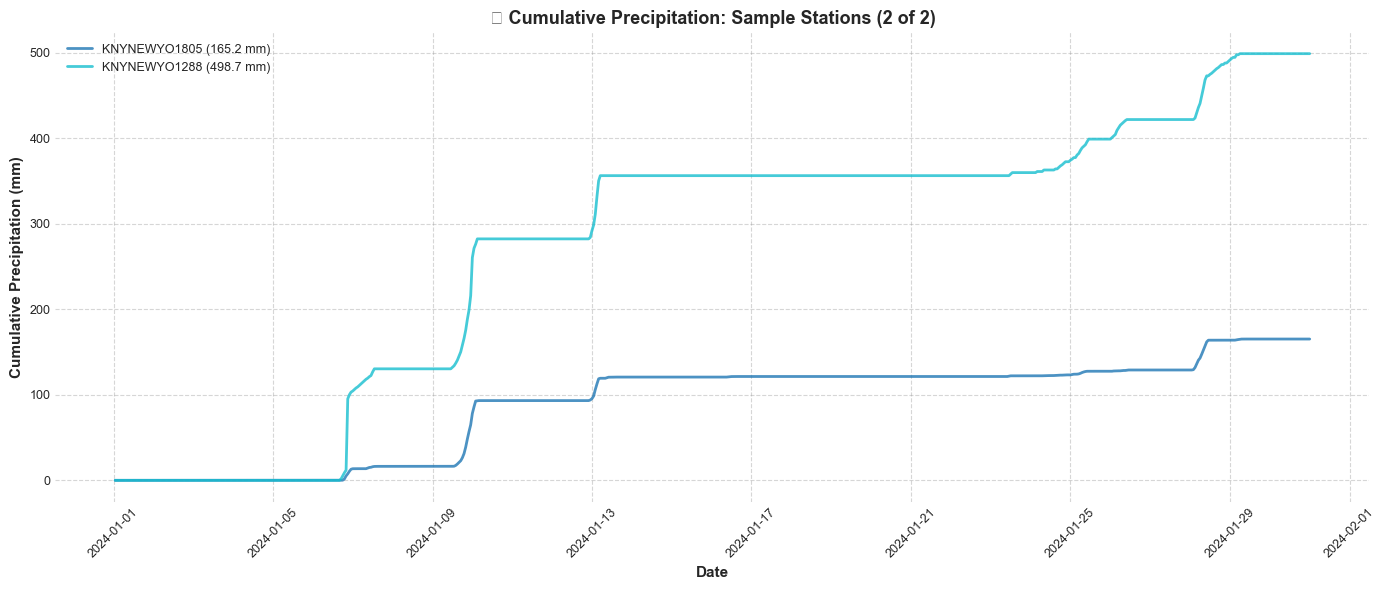

In [7]:
# Cumulative precipitation (sample of 3-4 stations in one plot)
if 'df' in locals() and len(df) > 0:
    plot_cumulative_precipitation(df, STATION_IDS[0], units=UNITS, show=False, verbose=False)
elif 'station_data' in locals():
    plot_cumulative_precipitation_multi(station_data, units=UNITS, show=False, max_stations=4, verbose=False)
else:
    print("❌ No data available")


## 4.2 Multi-Station Comparison: Accumulated Precipitation
Compare accumulated precipitation across all stations.


In [8]:
# Calculate accumulated precipitation per station
if 'station_data' in locals() and len(station_data) > 1:
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Collect accumulated precipitation for each station
    station_accumulated = {}
    station_stats = []
    
    precip_col = 'precip_rate' if 'precip_rate' in list(station_data.values())[0]['clean'].columns else 'precip_total'
    unit = 'mm' if UNITS == 'm' else 'in'
    
    for station_id, data in station_data.items():
        df_station = data['clean']
        if precip_col in df_station.columns:
            total_precip = df_station[precip_col].sum()
            station_accumulated[station_id] = total_precip
            
            # Additional stats
            rain_events = df_station[df_station[precip_col] > 0]
            daily_precip = df_station.groupby(df_station['time_local'].dt.date)[precip_col].sum()
            days_with_rain = (daily_precip > 0).sum()
            
            station_stats.append({
                'station_id': station_id,
                'total_precip': total_precip,
                'rain_hours': len(rain_events),
                'max_rate': df_station[precip_col].max(),
                'mean_rate': rain_events[precip_col].mean() if len(rain_events) > 0 else 0,
                'days_with_rain': days_with_rain
            })
    
    # Convert to DataFrame for easier analysis
    stats_df = pd.DataFrame(station_stats)
    stats_df = stats_df.sort_values('total_precip', ascending=False)
    
    print(f"📊 MULTI-STATION PRECIPITATION ANALYSIS")
    print("=" * 80)
    print(f"✅ Analyzed {len(station_accumulated)} stations")
    print(f"\n📈 Summary Statistics:")
    print(f"  • Mean accumulated: {stats_df['total_precip'].mean():.2f} {unit}")
    print(f"  • Median accumulated: {stats_df['total_precip'].median():.2f} {unit}")
    print(f"  • Min accumulated: {stats_df['total_precip'].min():.2f} {unit} ({stats_df.loc[stats_df['total_precip'].idxmin(), 'station_id']})")
    print(f"  • Max accumulated: {stats_df['total_precip'].max():.2f} {unit} ({stats_df.loc[stats_df['total_precip'].idxmax(), 'station_id']})")
    print(f"  • Std deviation: {stats_df['total_precip'].std():.2f} {unit}")
    
    print(f"\n🏆 Top 5 Stations by Accumulated Precipitation:")
    for i, row in stats_df.head(5).iterrows():
        print(f"  {i+1}. {row['station_id']}: {row['total_precip']:.2f} {unit}")
    
    print(f"\n📉 Bottom 5 Stations by Accumulated Precipitation:")
    for i, row in stats_df.tail(5).iterrows():
        print(f"  {i+1}. {row['station_id']}: {row['total_precip']:.2f} {unit}")
    
elif 'df' in locals():
    print("ℹ️ Single station mode - multi-station comparison not applicable")
    print("   Set USE_METADATA = True and load multiple stations for comparison")
else:
    print("❌ No data available")


📊 MULTI-STATION PRECIPITATION ANALYSIS
✅ Analyzed 2 stations

📈 Summary Statistics:
  • Mean accumulated: 331.96 mm
  • Median accumulated: 331.96 mm
  • Min accumulated: 165.17 mm (KNYNEWYO1805)
  • Max accumulated: 498.74 mm (KNYNEWYO1288)
  • Std deviation: 235.87 mm

🏆 Top 5 Stations by Accumulated Precipitation:
  2. KNYNEWYO1288: 498.74 mm
  1. KNYNEWYO1805: 165.17 mm

📉 Bottom 5 Stations by Accumulated Precipitation:
  2. KNYNEWYO1288: 498.74 mm
  1. KNYNEWYO1805: 165.17 mm


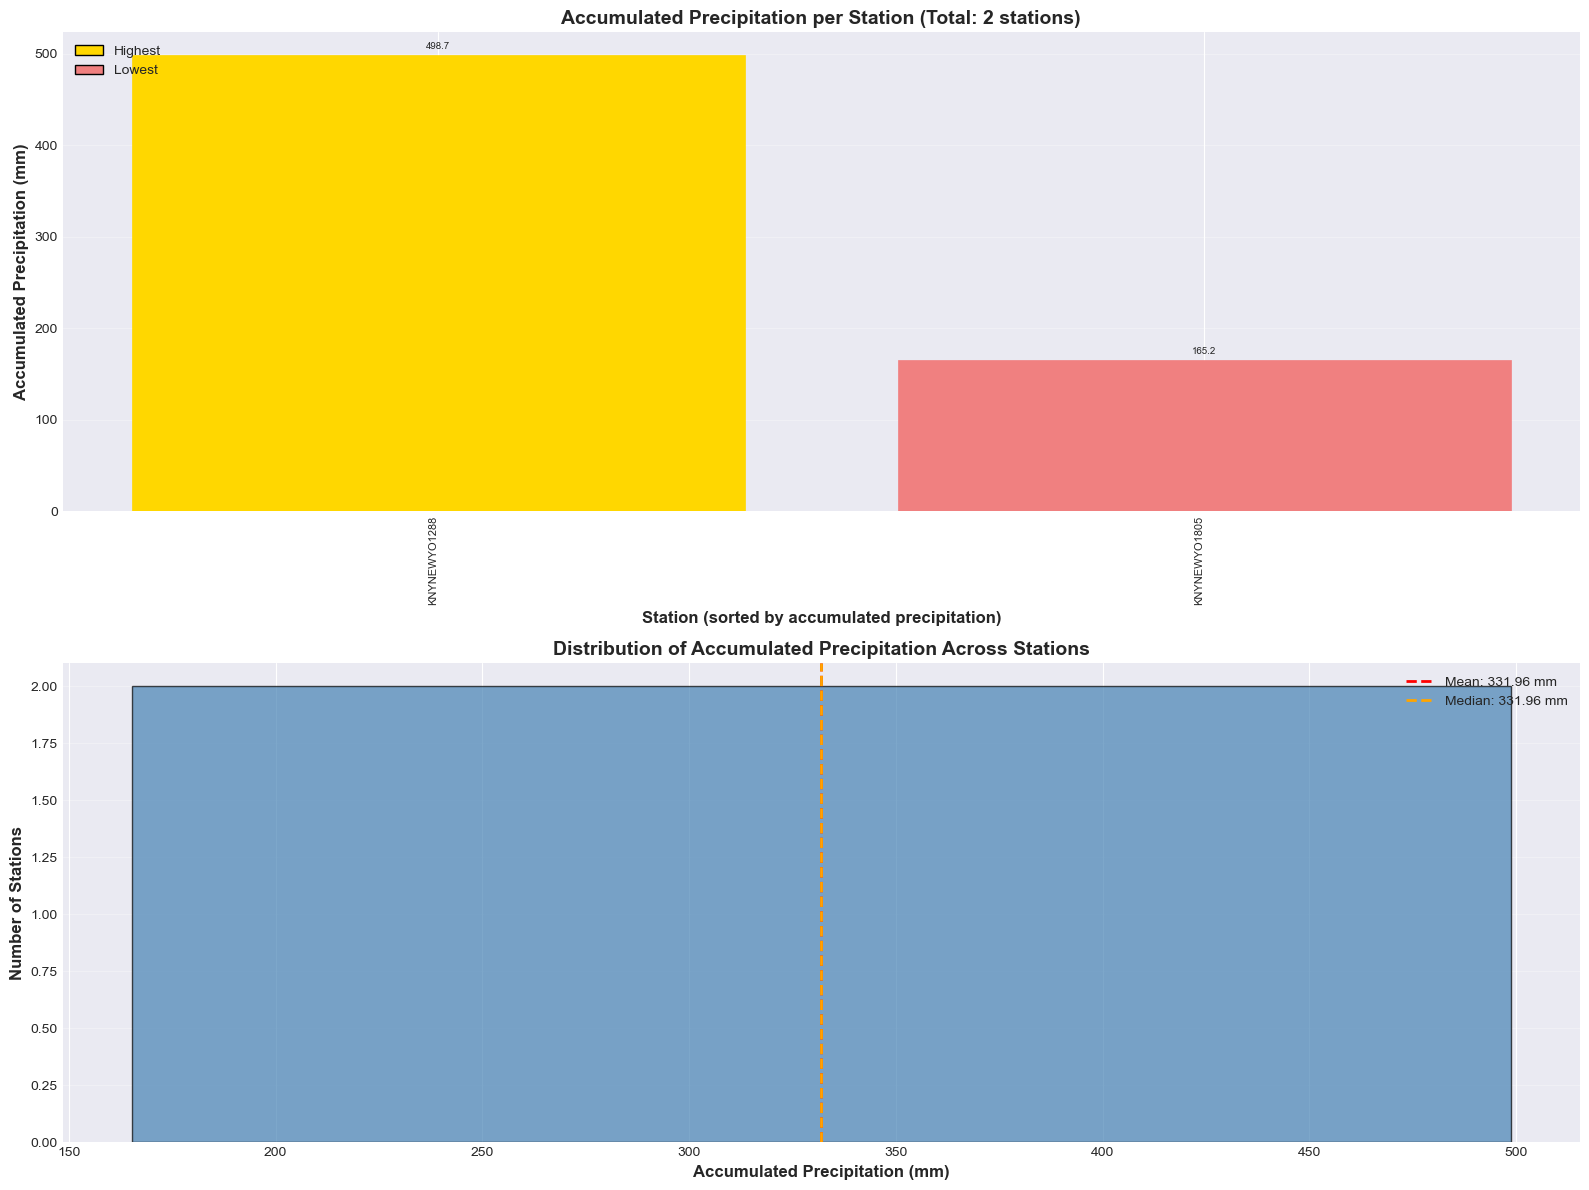

✅ Visualization complete!


In [9]:
# Visualize accumulated precipitation per station
if 'station_data' in locals() and len(station_data) > 1 and 'stats_df' in locals():
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Plot 1: Bar chart of accumulated precipitation per station
    ax1 = axes[0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(stats_df)))
    bars = ax1.bar(range(len(stats_df)), stats_df['total_precip'], color=colors, edgecolor='black', linewidth=0.5)
    
    # Highlight top and bottom stations
    top_idx = stats_df['total_precip'].idxmax()
    bottom_idx = stats_df['total_precip'].idxmin()
    bars[stats_df.index.get_loc(top_idx)].set_color('gold')
    bars[stats_df.index.get_loc(bottom_idx)].set_color('lightcoral')
    
    ax1.set_xlabel('Station (sorted by accumulated precipitation)', fontweight='bold', fontsize=12)
    ax1.set_ylabel(f'Accumulated Precipitation ({unit})', fontweight='bold', fontsize=12)
    ax1.set_title(f'Accumulated Precipitation per Station (Total: {len(stats_df)} stations)', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_xticks(range(len(stats_df)))
    ax1.set_xticklabels([sid[:12] + '...' if len(sid) > 12 else sid for sid in stats_df['station_id']], 
                        rotation=90, fontsize=8, ha='right')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(stats_df.iterrows()):
        ax1.text(i, row['total_precip'] + stats_df['total_precip'].max() * 0.01,
                f'{row["total_precip"]:.1f}',
                ha='center', va='bottom', fontsize=7, rotation=0)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gold', edgecolor='black', label='Highest'),
        Patch(facecolor='lightcoral', edgecolor='black', label='Lowest')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    # Plot 2: Distribution histogram
    ax2 = axes[1]
    ax2.hist(stats_df['total_precip'], bins=min(20, len(stats_df)//2), 
            color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(stats_df['total_precip'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {stats_df["total_precip"].mean():.2f} {unit}')
    ax2.axvline(stats_df['total_precip'].median(), color='orange', linestyle='--', 
               linewidth=2, label=f'Median: {stats_df["total_precip"].median():.2f} {unit}')
    ax2.set_xlabel(f'Accumulated Precipitation ({unit})', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Number of Stations', fontweight='bold', fontsize=12)
    ax2.set_title('Distribution of Accumulated Precipitation Across Stations', 
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualization complete!")
elif 'stats_df' not in locals():
    print("ℹ️ Run the previous cell first to calculate station statistics")
else:
    print("ℹ️ Single station mode - multi-station comparison not applicable")


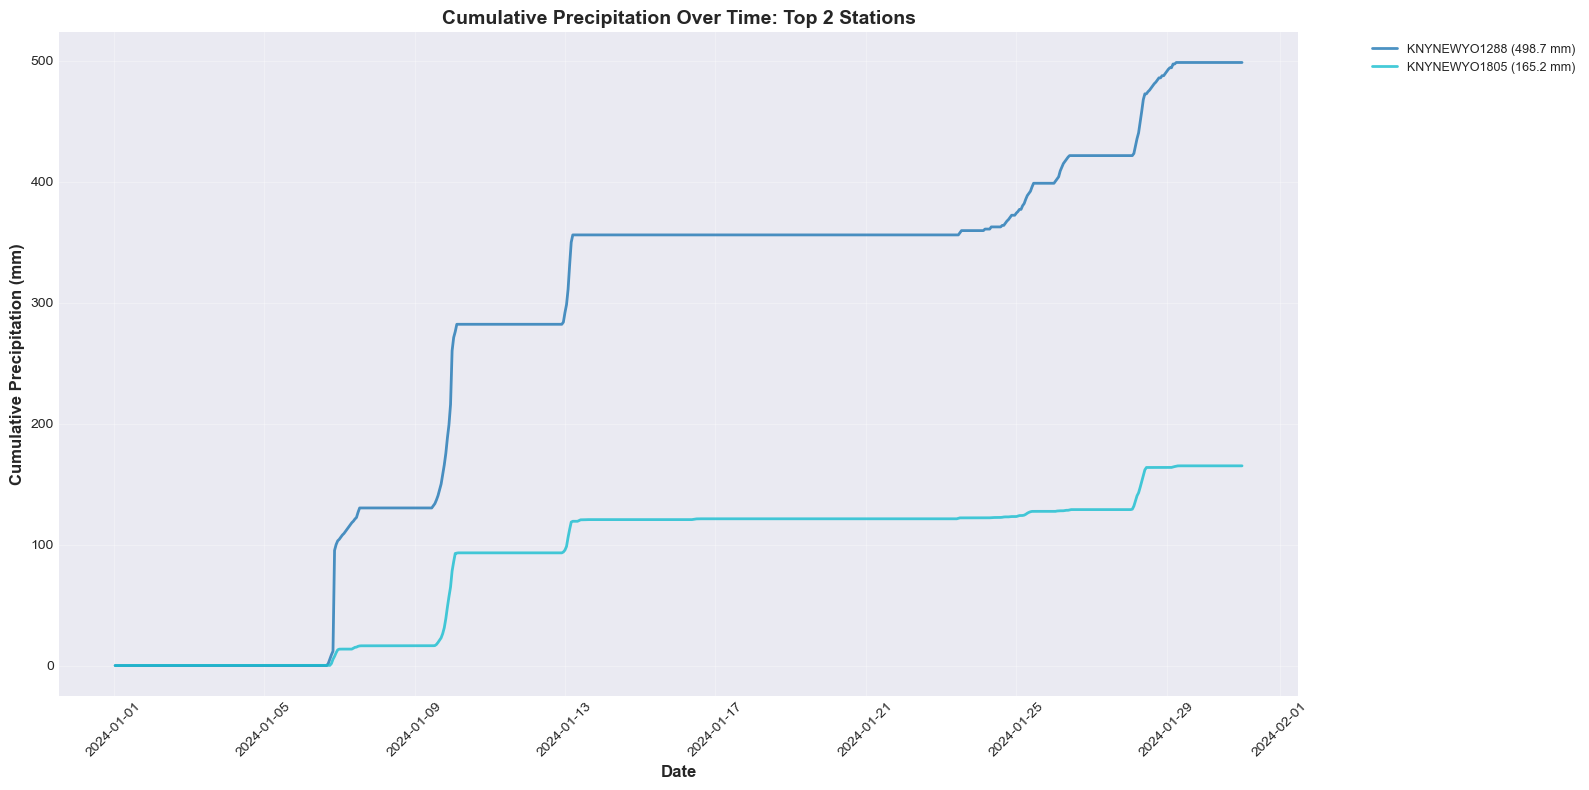

✅ Time series comparison for top 2 stations complete!

📊 Detailed Statistics for Top 2 Stations:
  station_id  total_precip  rain_hours  max_rate  mean_rate  days_with_rain
KNYNEWYO1288        498.74          98     83.31   5.089184              12
KNYNEWYO1805        165.17          99     13.28   1.668384              14


In [10]:
# Cumulative precipitation time series comparison (top stations)
if 'station_data' in locals() and len(station_data) > 1 and 'stats_df' in locals():
    # Select top N stations for comparison
    N_STATIONS = min(10, len(station_data))  # Compare top 10 stations
    
    top_stations = stats_df.head(N_STATIONS)['station_id'].tolist()
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    precip_col = 'precip_rate' if 'precip_rate' in list(station_data.values())[0]['clean'].columns else 'precip_total'
    unit = 'mm' if UNITS == 'm' else 'in'
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_stations)))
    
    for i, station_id in enumerate(top_stations):
        df_station = station_data[station_id]['clean'].copy()
        df_station['cumulative'] = df_station[precip_col].cumsum()
        
        ax.plot(df_station['time_local'], df_station['cumulative'],
               linewidth=2, label=f"{station_id} ({df_station['cumulative'].iloc[-1]:.1f} {unit})",
               color=colors[i], alpha=0.8)
    
    ax.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax.set_ylabel(f'Cumulative Precipitation ({unit})', fontweight='bold', fontsize=12)
    ax.set_title(f'Cumulative Precipitation Over Time: Top {N_STATIONS} Stations', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Time series comparison for top {N_STATIONS} stations complete!")
    
    # Also show summary table
    print(f"\n📊 Detailed Statistics for Top {N_STATIONS} Stations:")
    print("=" * 100)
    display_cols = ['station_id', 'total_precip', 'rain_hours', 'max_rate', 'mean_rate', 'days_with_rain']
    print(stats_df[display_cols].head(N_STATIONS).to_string(index=False))
    
elif 'stats_df' not in locals():
    print("ℹ️ Run the previous cell first to calculate station statistics")
elif 'station_data' in locals() and len(station_data) == 1:
    print("ℹ️ Single station mode - time series comparison not applicable")
else:
    print("❌ No data available")


## 5. Multi-Variable Dashboard


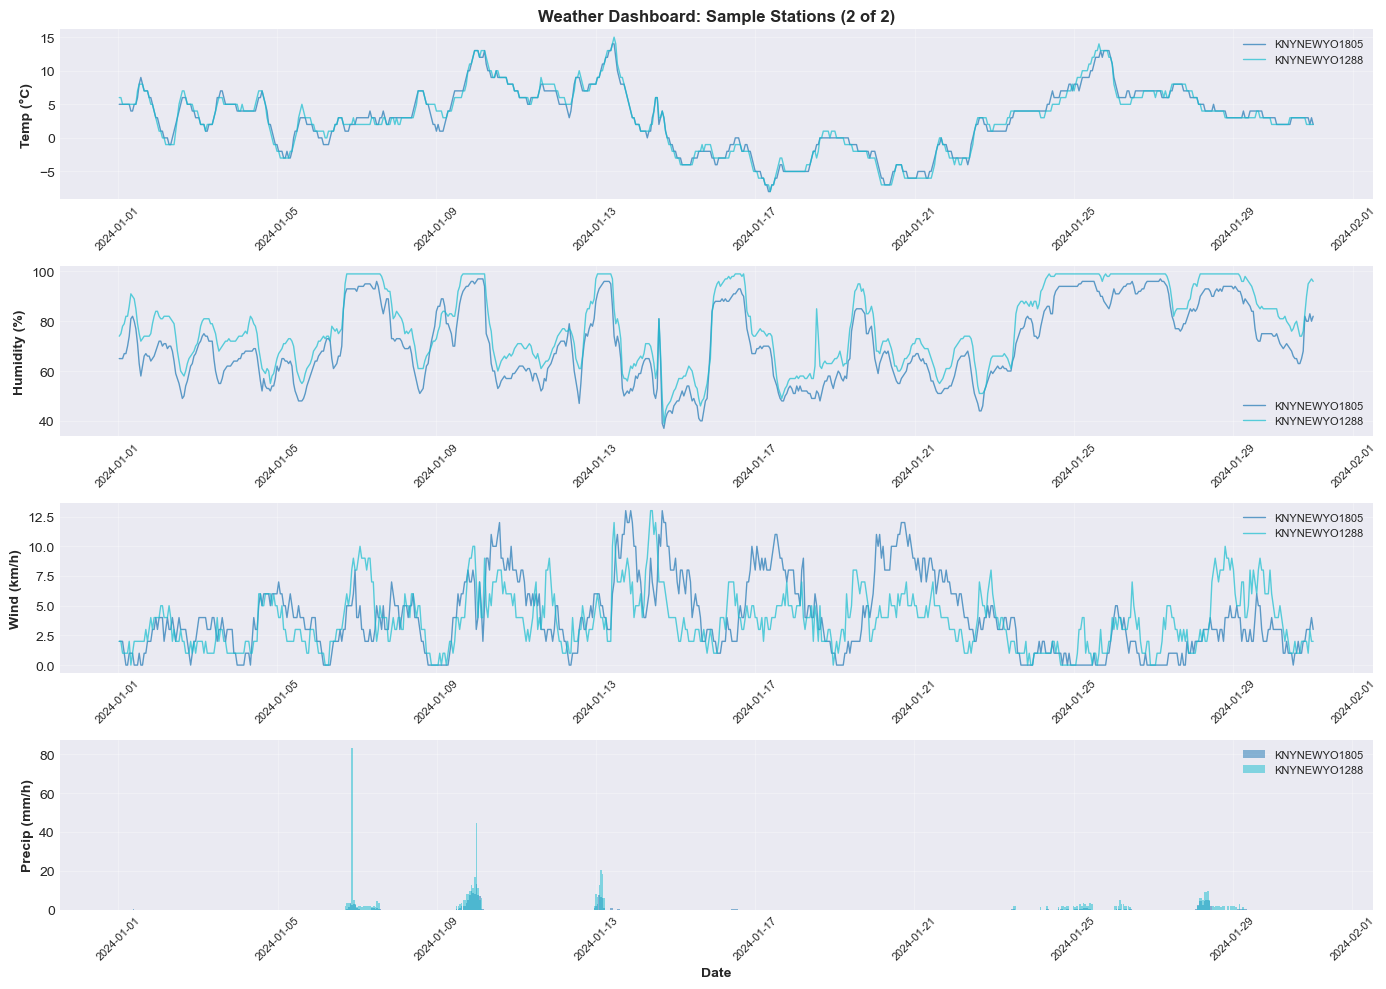

In [12]:
# Weather dashboard (sample of 3-4 stations in one plot)
if 'df' in locals() and len(df) > 0:
    plot_weather_dashboard(df, STATION_IDS[0], units=UNITS, show=False, verbose=False)
elif 'station_data' in locals():
    plot_weather_dashboard_multi(station_data, units=UNITS, show=False, max_stations=4, verbose=False)
else:
    print("❌ No data available")


## 7. Export Data


In [13]:
# Export data to multiple formats
if results:
    export_wu_data(
        results=results,
        output_dir=OUTPUT_DIR,
        start_date=START_DATE,
        end_date=END_DATE,
        export_all=False
    )


ℹ️ Export skipped (export_all=False)


## Quick Reference

### DataFrames Available:

**Single Station Mode:**
- `df_raw` - Original WU column names
- `df_clean` or `df` - Clean names (precipitation first!)
- `metadata` - Column descriptions

**Multiple Stations Mode:**
- `station_data` - Dictionary with all stations
  - `station_data[station_id]['raw']` - Original WU column names
  - `station_data[station_id]['clean']` - Clean names
  - `station_data[station_id]['metadata']` - Column descriptions

### Key Columns (Clean Names):
- `precip_rate` - Precipitation rate (mm/h or in/h)
- `precip_total` - Total precipitation (mm or in)
- `temp_avg` - Average temperature
- `humidity_avg` - Average humidity (%)
- `wind_speed_avg` - Average wind speed
- `time_local` - Local observation time

### Quick Commands:

**Single Station:**
```python
# View precipitation data
df[['time_local', 'precip_rate', 'precip_total']].head()

# Find rainy hours
df[df['precip_rate'] > 0]

# Daily totals
df.groupby(df['time_local'].dt.date)['precip_total'].sum()
```

**Multiple Stations:**
```python
# Access specific station
station_id = list(station_data.keys())[0]
df_station = station_data[station_id]['clean']

# Compare stations
for station_id, data in station_data.items():
    print(f"{station_id}: {data['clean']['precip_total'].sum():.2f} mm")
```

### Loading Stations from Metadata:
```python
# Load all stations from metadata CSV
pws_metadata = read_pws_metadata()
all_stations = get_station_list(pws_metadata)

# Filter by criteria
ny_stations = pws_metadata[pws_metadata['City'] == 'New York']['Station ID'].tolist()
```
